# Cell2Cell Churn Modeling Notebook

This notebook trains a linear classifier for churn prediction using the Cell2Cell dataset.  
It mirrors the original Python script, but is organized into modular cells for easier exploration.

> **Files expected in the working directory**  
> - `cell2celltrain.csv`  
> - `cell2cellholdout.csv`

## Setup & Paths

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
import inspect

# ---------------------------
# Paths (edit as needed)
# ---------------------------
TRAIN_PATH = "cell2celltrain.csv"
HOLDOUT_PATH = "cell2cellholdout.csv"
PRED_OUT = "churn_predictions_holdout.csv"
COEF_OUT = "sgd_logreg_feature_importance.csv"

print(os.listdir('.'))

['.git', '.ipynb_checkpoints', 'cell2cellholdout.csv', 'cell2celltrain.csv', 'cell2cell_churn_model.ipynb', 'churn_linear.py', 'README.md', 'requirements.txt', 'Untitled.ipynb']


## Utility Functions

In [5]:
def find_target_column(df):
    candidates = ['Churn', 'churn', 'CHURN']
    for c in df.columns:
        if c in candidates:
            return c
    for c in df.columns:
        if 'churn' in c.lower():
            return c
    binary_like = [c for c in df.columns if df[c].nunique(dropna=True) == 2]
    return binary_like[0] if binary_like else df.columns[-1]

def to_binary(series: pd.Series) -> pd.Series:
    if series.dtype.name == "category":
        series = series.astype(str)
    if series.dtype == bool:
        return series.astype(int)
    s = series.astype(str).str.strip().str.lower()
    true_vals = {'yes', 'true', '1', 'churned', 'y', 't'}
    return s.isin(true_vals).astype(int)

def build_preprocessor(X: pd.DataFrame):
    # Split columns
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    # Numeric: impute + scale (dense)
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    ohe_kwargs = {"handle_unknown": "ignore"}
    params = inspect.signature(OneHotEncoder).parameters

    if "sparse_output" in params:
        ohe_kwargs["sparse_output"] = True
    elif "sparse" in params:
        ohe_kwargs["sparse"] = True

    if "min_frequency" in params:
        ohe_kwargs["min_frequency"] = 0.01 

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(**ohe_kwargs)),
    ])

    preprocess = ColumnTransformer([
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),
    ])

    return preprocess, numeric_cols, categorical_cols

## Load Data

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
holdout_df = pd.read_csv(HOLDOUT_PATH)
print(train_df.shape, holdout_df.shape)
train_df.head()

(51047, 58) (20000, 58)


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## Feature & Target Preparation

In [7]:
target_col = find_target_column(train_df)
y = to_binary(train_df[target_col])

id_like = [c for c in train_df.columns
           if any(tok in c.lower() for tok in ['id', 'customer', 'account'])]
feature_cols = [c for c in train_df.columns if c not in {target_col, *id_like}]
X = train_df[feature_cols].copy()

holdout_feature_cols = [c for c in holdout_df.columns if c in feature_cols]
X_holdout = holdout_df[holdout_feature_cols].copy()

preprocess, num_cols, cat_cols = build_preprocessor(X)

print(f"Target column: {target_col}")
print(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

Target column: Churn
Numeric cols: 33, Categorical cols: 22


## Choose Model (SGD logistic vs. exact LogisticRegression)

In [9]:
use_exact_logreg = False  # set True to use LogisticRegression(saga)

if use_exact_logreg:
    clf = LogisticRegression(
        penalty="l2",
        solver="saga",
        max_iter=5000,
        n_jobs=-1
    )
else:
    clf = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-4,
        max_iter=5000,
        early_stopping=True,
        n_iter_no_change=5,
        class_weight="balanced",
        random_state=42
    )

model = Pipeline([("preprocess", preprocess), ("clf", clf)])

## Train / Validation Split & Fit

In [10]:
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_tr, y_tr)
print("Model fitted.")

Model fitted.


## Validation Metrics


=== Validation Results ===
AUC:       0.5572
Accuracy:  0.5093
Confusion matrix:
 [[3372 3896]
 [1114 1828]]

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.46      0.57      7268
           1       0.32      0.62      0.42      2942

    accuracy                           0.51     10210
   macro avg       0.54      0.54      0.50     10210
weighted avg       0.63      0.51      0.53     10210



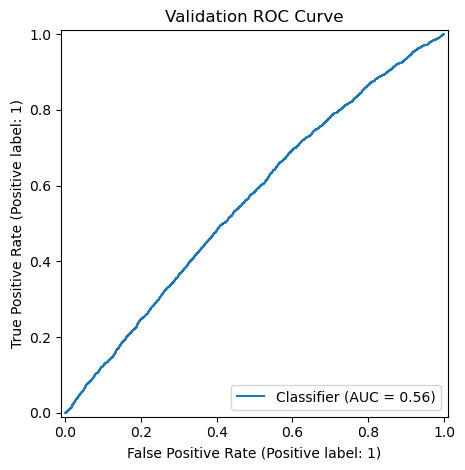

In [11]:
yva_proba = model.predict_proba(X_va)[:, 1]
yva_pred = (yva_proba >= 0.5).astype(int)

valid_auc = roc_auc_score(y_va, yva_proba)
valid_acc = accuracy_score(y_va, yva_pred)
valid_cm = confusion_matrix(y_va, yva_pred)

print("\n=== Validation Results ===")
print(f"AUC:       {valid_auc:.4f}")
print(f"Accuracy:  {valid_acc:.4f}")
print("Confusion matrix:\n", valid_cm)
print("\nClassification report:\n", classification_report(y_va, yva_pred))

# Plot ROC (validation) - single plot, default matplotlib styles
RocCurveDisplay.from_predictions(y_va, yva_proba)
plt.title("Validation ROC Curve")
plt.tight_layout()
plt.show()

## Holdout Predictions & (Optional) Evaluation

In [12]:
yhold_proba = model.predict_proba(X_holdout)[:, 1]
yhold_pred = (yhold_proba >= 0.5).astype(int)

has_holdout_label = False
if target_col in holdout_df.columns:
    y_hold = to_binary(holdout_df[target_col])
    if y_hold.nunique(dropna=True) >= 2:
        has_holdout_label = True

if has_holdout_label:
    hold_auc = roc_auc_score(y_hold, yhold_proba)
    hold_acc = accuracy_score(y_hold, yhold_pred)
    hold_cm = confusion_matrix(y_hold, yhold_pred)
    print("\n=== Holdout Results ===")
    print(f"AUC:       {hold_auc:.4f}")
    print(f"Accuracy:  {hold_acc:.4f}")
    print("Confusion matrix:\n", hold_cm)
    print("\nClassification report:\n", classification_report(y_hold, yhold_pred))
    RocCurveDisplay.from_predictions(y_hold, yhold_proba)
    plt.title("Holdout ROC Curve")
    plt.tight_layout()
    plt.show()
else:
    print("\n(Info) Holdout labels are missing or single-class; saving predictions only.")

preds_df = holdout_df.copy()
preds_df["pred_proba_churn"] = yhold_proba
preds_df["pred_label"] = yhold_pred
preds_df.to_csv(PRED_OUT, index=False)
print(f"\nSaved holdout predictions to: {PRED_OUT}")
preds_df.head()


(Info) Holdout labels are missing or single-class; saving predictions only.

Saved holdout predictions to: churn_predictions_holdout.csv


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,pred_proba_churn,pred_label
0,3000006,NaN,57.49,483.0,37.0,0.25,23.0,0.0,532.0,51.0,...,No,1,150,No,5-Low,Other,Other,No,0.063006,0
1,3000018,NaN,55.23,570.0,72.0,0.00,0.0,0.0,38.0,0.0,...,No,2,80,No,1-Highest,Other,Professional,No,0.077413,0
2,3000034,NaN,97.34,1039.0,50.0,4.95,420.0,0.0,198.0,23.3,...,No,3,10,No,3-Good,Suburban,Crafts,Yes,0.688455,1
3,3000070,NaN,35.59,153.0,30.0,0.00,16.0,0.0,30.0,7.3,...,No,1,200,No,1-Highest,Other,Other,No,0.125350,0
4,3000074,NaN,55.27,1213.0,50.0,0.74,0.0,1.3,169.0,1.0,...,No,0,10,No,1-Highest,Suburban,Other,No,0.088729,0


## Extract Coefficients / Feature Importance

In [13]:
def extract_feature_names(preprocess, num_cols, cat_cols):
    feature_names = []
    # numeric features (unchanged order)
    feature_names.extend(num_cols)

    # categorical features from OneHotEncoder
    # Find the 'onehot' step within the 'cat' transformer
    cat_transformer = None
    for name, trans, cols in preprocess.transformers_:
        if name == "cat":
            # 'trans' is a Pipeline; get OneHotEncoder step
            cat_transformer = trans.named_steps.get("onehot", None)
            cat_cols_used = cols
            break

    if cat_transformer is not None:
        # get_feature_names_out requires the original column names for the OHE
        try:
            ohe_feature_names = cat_transformer.get_feature_names_out(cat_cols_used)
        except TypeError:
            # For older versions where get_feature_names_out() has no args
            ohe_feature_names = cat_transformer.get_feature_names_out()
        feature_names.extend(list(ohe_feature_names))
    return feature_names

# Now extract coefficients and save
preprocess_fitted = model.named_steps["preprocess"]
feature_names = extract_feature_names(preprocess_fitted, num_cols, cat_cols)
coefs = model.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})             .sort_values("coefficient", ascending=False)
coef_df.to_csv(COEF_OUT, index=False)
print(f"Saved coefficients to: {COEF_OUT}")

# Show top signals
top_pos = coef_df.head(15)
top_neg = coef_df.tail(15)

print("\nTop positive churn signals:")
display(top_pos)

print("\nTop negative (retention) signals:")
display(top_neg)

Saved coefficients to: sgd_logreg_feature_importance.csv

Top positive churn signals:


,feature,coefficient
4,OverageMinutes,0.699335
18,CallForwardingCalls,0.543251
91,CreditRating_1-Highest,0.424238
46,ServiceArea_SFRSCL408,0.414662
8,DroppedCalls,0.341816
52,HandsetRefurbished_Yes,0.312582
13,OutboundCalls,0.276504
106,Occupation_Retired,0.256680
0,MonthlyRevenue,0.242375
19,CallWaitingCalls,0.237158



Top negative (retention) signals:


,feature,coefficient
109,MaritalStatus_No,-0.164312
93,CreditRating_3-Good,-0.167611
86,HandsetPrice_80,-0.169230
51,HandsetRefurbished_No,-0.234058
12,ReceivedCalls,-0.253762
32,AdjustmentsToCreditRating,-0.257210
87,HandsetPrice_Unknown,-0.263084
17,DroppedBlockedCalls,-0.272976
20,MonthsInService,-0.298498
38,ServiceArea_DALFTW817,-0.305510


## Notes

- `use_exact_logreg = False` uses an `SGDClassifier` with `log_loss` for efficiency on large, sparse features.
- Set `use_exact_logreg = True` for `LogisticRegression(saga)` if you need exact solvers (slower on wide one-hot features).
- Paths can be changed at the top if your CSVs live elsewhere.